# EMAIL SPAM CLASSIFIER USING NLP

## Import necessary Libraries

In [123]:
import spacy
import string
import pandas as pd
import numpy as np
import re    # re for regular expressions, this import is used for text preprocessing
from sklearn.svm import LinearSVC 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
nlp = spacy.load('en_core_web_sm')

In [124]:
from spacy.lang.en.stop_words import STOP_WORDS

# Convert spaCy stopwords to a set (faster lookups)
stopwords = set(word.lower() for word in STOP_WORDS)

# Add custom email-specific stopwords
email_stopwords = {
    'email', 'mail', 'send', 'sent', 'message', 
    'subject', 'dear', 'hello', 'hi', 'regards', 'sincerely'
}
stopwords.update(email_stopwords)

# Words important for spam classification (don't remove them)
spam_important_words = {
    'free', 'win', 'money', 'urgent', 
    'limited', 'offer', 'now', 'only', 'today'
}
stopwords.difference_update(spam_important_words)

print(f"Total stopwords: {len(stopwords)}")
print(f"Sample stopwords: {list(stopwords)[:10]}")


Total stopwords: 335
Sample stopwords: ['show', 'side', 'our', 'was', 'neither', 'regards', 'thru', 'using', 'last', 'call']


## Load the Dataset and Visualization

In [125]:
data_spam = pd.read_csv('Dataset/emails.csv')

# Display basic dataset information
print(f"Dataset shape: {data_spam.shape}")
print(f"Column names: {data_spam.columns.tolist()}")
print(f"\nDataset info:")
print(data_spam.info())

# Check the distribution of spam vs ham
print(f"\nLabel distribution:")
print(data_spam['spam'].value_counts())
print(f"\nLabel distribution (percentages):")
print(data_spam['spam'].value_counts(normalize=True) * 100)

data_spam.head()

Dataset shape: (5728, 2)
Column names: ['text', 'spam']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None

Label distribution:
spam
0    4360
1    1368
Name: count, dtype: int64

Label distribution (percentages):
spam
0    76.117318
1    23.882682
Name: proportion, dtype: float64


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## Data Exploration and Analysis 

In [126]:
# Check for any missing or duplicate data
print(f"\nMissing values: {data_spam.isnull().sum()}")
print(f"\nDuplicate emails: {data_spam.duplicated().sum()}")

# Analyze email lengths
data_spam['text_length'] = data_spam['text'].str.len()
data_spam['word_count'] = data_spam['text'].str.split().str.len()


print(f"Email length statistics:")
print(data_spam.groupby('spam')[['text_length', 'word_count']].describe())




Missing values: text    0
spam    0
dtype: int64

Duplicate emails: 33
Email length statistics:
     text_length                                                           \
           count         mean          std   min     25%     50%      75%   
spam                                                                        
0         4360.0  1631.918119  1959.664549  13.0  577.75  1122.0  2037.25   
1         1368.0  1317.257310  2271.372893  18.0  401.50   693.5  1250.25   

              word_count                                                     \
          max      count        mean         std  min    25%    50%     75%   
spam                                                                          
0     43952.0     4360.0  345.804817  406.189568  2.0  119.0  239.0  439.25   
1     28432.0     1368.0  266.432749  451.461674  4.0   79.0  139.5  251.00   

              
         max  
spam          
0     8477.0  
1     6129.0  


In [127]:
# Remove duplicate rows
data_spam_1 = data_spam.copy()
before_shape = data_spam_1.shape

data_spam_1.drop_duplicates(inplace=True)
after_shape = data_spam_1.shape

# Report how many duplicates were removed
removed = before_shape[0] - after_shape[0]
print(f"Removed {removed} duplicate rows")
print(f"After cleaning: {after_shape}")

# Reset index for cleanliness
data_spam_1.reset_index(drop=True, inplace=True)

# Optionally, save the cleaned data
data_spam_1.to_csv('Dataset/emails_cleaned.csv', index=False)
print("Cleaned dataset saved as 'Dataset/emails_cleaned.csv'")

# Sanity checks
print("\nMissing values per column:")
print(data_spam_1.isnull().sum())

print(f"\nRemaining duplicate emails: {data_spam_1.duplicated().sum()}")


Removed 33 duplicate rows
After cleaning: (5695, 4)
Cleaned dataset saved as 'Dataset/emails_cleaned.csv'

Missing values per column:
text           0
spam           0
text_length    0
word_count     0
dtype: int64

Remaining duplicate emails: 0


In [128]:
import string

# Sample emails from each class
print("SAMPLE HAM EMAIL:")
sample_ham = data_spam_1[data_spam_1['spam'] == 0]['text'].sample(1).values[0]
print(sample_ham[:300], "...")  # preview first 300 characters

print("\nSAMPLE SPAM EMAIL:")
sample_spam = data_spam_1[data_spam_1['spam'] == 1]['text'].sample(1).values[0]
print(sample_spam[:300], "...")  # preview first 300 characters

# Define punctuation to remove
punctuation = string.punctuation
print(f"\nPunctuation marks to remove: {punctuation}")


SAMPLE HAM EMAIL:
Subject: listo 319  isranir @ rice . edu , demianen @ rice . edu , tbal 93 @ yahoo . com , maue @ rice . edu ,  loughrid @ rice . edu , jblantonjr @ yahoo . com , gjohnson @ rice . edu ,  emchombo @ rice . edu , nazareth @ rice . edu , vanstone @ rice . edu , ganguzza @ rice . edu ,  nelsonb @ rice  ...

SAMPLE SPAM EMAIL:
Subject: save your money by getting an oem software !  need in software for your pc ? just visit our site , we might have what you need . . .  best regards ,  vesta  ...

Punctuation marks to remove: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


## Enhanced cleaning function for email spam detection

In [129]:
def clean_email_text(email_text):
    """
    Clean email text for spam classification:
    - Remove email addresses, URLs, phone numbers, excessive whitespace
    - Apply lemmatization and remove stopwords
    - Preserve important spam indicator words
    """
    # Remove email addresses
    email_text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', ' ', email_text)
    
    # Remove URLs
    email_text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', email_text)
    
    # Remove phone numbers (basic formats)
    email_text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' ', email_text)
    
    # Remove excessive whitespace
    email_text = re.sub(r'\s+', ' ', email_text)
    
    # Process with spaCy
    doc = nlp(email_text)
    tokens = []
    
    for token in doc:
        temp = token.lemma_.lower().strip() if token.lemma_ != '-PRON-' else token.lower_
        tokens.append(temp)
    
    # Filter tokens
    clean_tokens = [
        token for token in tokens
        if (token.isalpha() and
            token not in punctuation and
            token not in stopwords and
            len(token) > 2 and
            not token.isdigit())
    ]
    
    # Return as string for TF-IDF
    return " ".join(clean_tokens)

# Test the function
test_email = data_spam_1['text'].iloc[0]
print(f"Original: {test_email[:300]}...")
cleaned_text = clean_email_text(test_email)
print(f"Cleaned text: {cleaned_text[:300]}...")


Original: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that h...
Cleaned text: naturally irresistible corporate identity hard recollect company market suqgestion information isoverwhelminq good catchy logo stylish statlonery outstanding website task easy promise havinq order iogo company automaticaily world ieader isguite ciear good product effective business organization prac...


## Data Splitting 

In [130]:
# Features and labels
X = data_spam_1['text']  # Email text content
y = data_spam_1['spam']  # Labels (0=ham, 1=spam)

# Stratified split (maintains class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display split info
print(f"Training set size: {X_train.shape[0]} emails")
print(f"Test set size: {X_test.shape[0]} emails")
print(f"Total dataset: {len(data_spam_1)} emails")

# Check if stratification maintained distribution
dist = pd.DataFrame({
    "Original (%)": y.value_counts(normalize=True)*100,
    "Train (%)": y_train.value_counts(normalize=True)*100,
    "Test (%)": y_test.value_counts(normalize=True)*100
})
print("\nSpam/Ham distribution (%):")
print(dist)


Training set size: 4556 emails
Test set size: 1139 emails
Total dataset: 5695 emails

Spam/Ham distribution (%):
      Original (%)  Train (%)  Test (%)
spam                                   
0        75.978929  75.987709  75.94381
1        24.021071  24.012291  24.05619


## Model Pipeline Section

In [131]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# TF-IDF Vectorizer with custom email cleaning
tfidf = TfidfVectorizer(
    analyzer='word',           # ensures tokenizer is used correctly
    tokenizer=clean_email_text,
    lowercase=True,
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words=None
)

# Linear SVM classifier
svm_classifier = LinearSVC(
    random_state=42,
    class_weight='balanced',
    max_iter=10000,
    C=1.0
)

# Pipeline creation
spam_classifier_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('classifier', svm_classifier)
])

print("Pipeline created successfully!")
print(f"Pipeline steps: {spam_classifier_pipeline.named_steps.keys()}")


Pipeline created successfully!
Pipeline steps: dict_keys(['tfidf', 'classifier'])


## Training the Model 

In [132]:
import time

# Start training
training_start = time.time()

# Train the pipeline (TF-IDF + SVM)
spam_classifier_pipeline.fit(X_train, y_train)

# Calculate training time
training_time = time.time() - training_start

print(f"Model training completed successfully!")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training samples: {len(X_train):,} emails")

# Vocabulary size
vocab_size = len(spam_classifier_pipeline.named_steps['tfidf'].vocabulary_)
print(f"Vocabulary size: {vocab_size:,} features")

# TF-IDF matrix shape for sanity check
tfidf_component = spam_classifier_pipeline.named_steps['tfidf']
print(f"TF-IDF matrix shape: {tfidf_component.transform(X_train).shape}")

print("Model ready for predictions!")


Model training completed successfully!
Training time: 189.07 seconds
Training samples: 4,556 emails
Vocabulary size: 722 features
TF-IDF matrix shape: (4556, 722)
Model ready for predictions!


## Model Predictions 

In [133]:
import time
import numpy as np

# Record prediction start time
prediction_start = time.time()

# Make predictions on test data
y_pred = spam_classifier_pipeline.predict(X_test)

# Decision scores for additional analysis
y_scores = spam_classifier_pipeline.decision_function(X_test)

# Calculate prediction time
prediction_time = time.time() - prediction_start

print(f"Predictions completed successfully!")
print(f"Prediction time: {prediction_time:.4f} seconds")
print(f"Test samples: {len(X_test):,} emails")
print(f"Predictions generated: {len(y_pred):,}")

# Prediction distribution
unique, counts = np.unique(y_pred, return_counts=True)
pred_distribution = dict(zip(unique, counts))

print(f"\nPREDICTION DISTRIBUTION")
print(f"Predicted HAM (0): {pred_distribution.get(0,0)} emails ({pred_distribution.get(0,0)/len(y_pred)*100:.1f}%)")
print(f"Predicted SPAM (1): {pred_distribution.get(1,0)} emails ({pred_distribution.get(1,0)/len(y_pred)*100:.1f}%)")

# Actual vs Predicted comparison
actual_ham_count = (y_test == 0).sum()
actual_spam_count = (y_test == 1).sum()
pred_ham_count = pred_distribution.get(0,0)
pred_spam_count = pred_distribution.get(1,0)

print(f"\nACTUAL vs PREDICTED COMPARISON")
print(f"Actual:    HAM={actual_ham_count} ({actual_ham_count/len(y_test)*100:.1f}%), SPAM={actual_spam_count} ({actual_spam_count/len(y_test)*100:.1f}%)")
print(f"Predicted: HAM={pred_ham_count} ({pred_ham_count/len(y_pred)*100:.1f}%), SPAM={pred_spam_count} ({pred_spam_count/len(y_pred)*100:.1f}%)")


Predictions completed successfully!
Prediction time: 94.9123 seconds
Test samples: 1,139 emails
Predictions generated: 1,139

PREDICTION DISTRIBUTION
Predicted HAM (0): 831 emails (73.0%)
Predicted SPAM (1): 308 emails (27.0%)

ACTUAL vs PREDICTED COMPARISON
Actual:    HAM=865 (75.9%), SPAM=274 (24.1%)
Predicted: HAM=831 (73.0%), SPAM=308 (27.0%)


## Evaluate the Model

In [134]:
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support, confusion_matrix
import numpy as np

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

# Detailed classification report
class_names = ['HAM (Legitimate)', 'SPAM (Unwanted)']
print("DETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Class-wise precision, recall, f1
precision, recall, f1_scores, support = precision_recall_fscore_support(y_test, y_pred, average=None)
print("CLASS-WISE METRICS")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1-Score={f1_scores[i]:.4f}, Support={support[i]}")

# Macro and weighted averages
print("\nAVERAGED METRICS")
print(f"Macro Average    - Precision: {precision.mean():.4f}, Recall: {recall.mean():.4f}, F1: {f1_scores.mean():.4f}")
print(f"Weighted Average - Precision: {np.average(precision, weights=support):.4f}, Recall: {np.average(recall, weights=support):.4f}, F1: {np.average(f1_scores, weights=support):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nCONFUSION MATRIX (Actual vs Predicted)")
print(f"                 Predicted")
print(f"Actual    HAM    SPAM")
print(f"HAM      {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"SPAM     {cm[1,0]:4d}   {cm[1,1]:4d}")

# Error analysis
true_negatives, false_positives = cm[0,0], cm[0,1]
false_negatives, true_positives = cm[1,0], cm[1,1]
print("\nERROR ANALYSIS")
print(f"True Negatives (HAM → HAM):   {true_negatives}")
print(f"True Positives (SPAM → SPAM): {true_positives}")
print(f"False Positives (HAM → SPAM): {false_positives} (Important emails marked as spam!)")
print(f"False Negatives (SPAM → HAM): {false_negatives} (Spam emails in inbox)")


Overall Accuracy: 0.9526 (95.26%)

DETAILED CLASSIFICATION REPORT
                  precision    recall  f1-score   support

HAM (Legitimate)     0.9880    0.9491    0.9682       865
 SPAM (Unwanted)     0.8571    0.9635    0.9072       274

        accuracy                         0.9526      1139
       macro avg     0.9226    0.9563    0.9377      1139
    weighted avg     0.9565    0.9526    0.9535      1139

CLASS-WISE METRICS
HAM (Legitimate): Precision=0.9880, Recall=0.9491, F1-Score=0.9682, Support=865
SPAM (Unwanted): Precision=0.8571, Recall=0.9635, F1-Score=0.9072, Support=274

AVERAGED METRICS
Macro Average    - Precision: 0.9226, Recall: 0.9563, F1: 0.9377
Weighted Average - Precision: 0.9565, Recall: 0.9526, F1: 0.9535

CONFUSION MATRIX (Actual vs Predicted)
                 Predicted
Actual    HAM    SPAM
HAM       821     44
SPAM       10    264

ERROR ANALYSIS
True Negatives (HAM → HAM):   821
True Positives (SPAM → SPAM): 264
False Positives (HAM → SPAM): 44 (Importan

## Performance Analysis 

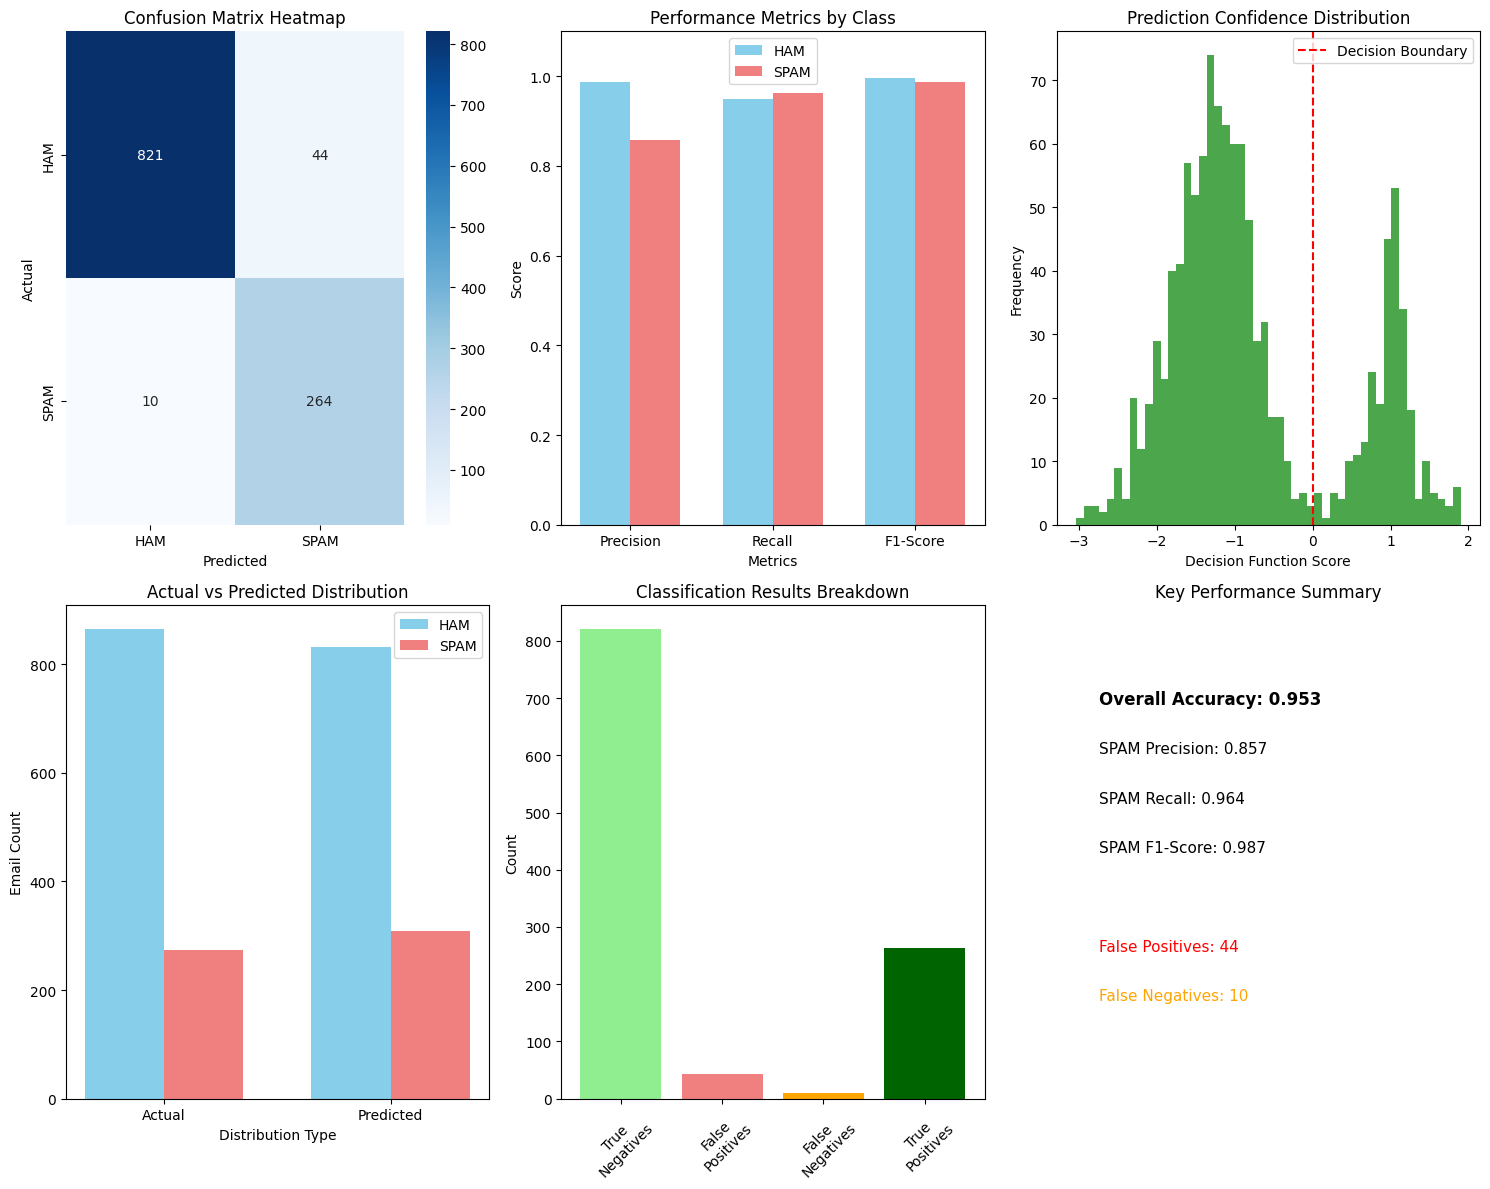

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(15, 12))
width = 0.35

# 1. Confusion Matrix Heatmap
plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HAM', 'SPAM'], yticklabels=['HAM', 'SPAM'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 2. Performance Metrics Bar Chart
plt.subplot(2, 3, 2)
metrics = ['Precision', 'Recall', 'F1-Score']
ham_scores = [precision[0], recall[0], f1_score[0]]
spam_scores = [precision[1], recall[1], f1_score[1]]
x = np.arange(len(metrics))
plt.bar(x - width/2, ham_scores, width, label='HAM', color='skyblue')
plt.bar(x + width/2, spam_scores, width, label='SPAM', color='lightcoral')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Performance Metrics by Class')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1.1)

# 3. Prediction Confidence Distribution
plt.subplot(2, 3, 3)
plt.hist(y_pred_proba, bins=50, alpha=0.7, color='green')
plt.xlabel('Decision Function Score')
plt.ylabel('Frequency')
plt.title('Prediction Confidence Distribution')
plt.axvline(x=0, color='red', linestyle='--', label='Decision Boundary')
plt.legend()

# 4. Class Distribution Comparison
plt.subplot(2, 3, 4)
categories = ['Actual', 'Predicted']
ham_counts = [actual_ham_count, pred_ham_count]
spam_counts = [actual_spam_count, pred_spam_count]
x = np.arange(len(categories))
plt.bar(x - width/2, ham_counts, width, label='HAM', color='skyblue')
plt.bar(x + width/2, spam_counts, width, label='SPAM', color='lightcoral')
plt.xlabel('Distribution Type')
plt.ylabel('Email Count')
plt.title('Actual vs Predicted Distribution')
plt.xticks(x, categories)
plt.legend()

# 5. Error Rate Analysis
plt.subplot(2, 3, 5)
error_types = ['True\nNegatives', 'False\nPositives', 'False\nNegatives', 'True\nPositives']
error_counts = [true_negatives, false_positives, false_negatives, true_positives]
colors = ['lightgreen', 'lightcoral', 'orange', 'darkgreen']
plt.bar(error_types, error_counts, color=colors)
plt.title('Classification Results Breakdown')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 6. Performance Summary
plt.subplot(2, 3, 6)
plt.text(0.1, 0.8, f'Overall Accuracy: {accuracy:.3f}', fontsize=12, weight='bold')
plt.text(0.1, 0.7, f'SPAM Precision: {precision[1]:.3f}', fontsize=11)
plt.text(0.1, 0.6, f'SPAM Recall: {recall[1]:.3f}', fontsize=11)
plt.text(0.1, 0.5, f'SPAM F1-Score: {f1_score[1]:.3f}', fontsize=11)
plt.text(0.1, 0.3, f'False Positives: {false_positives}', fontsize=11, color='red')
plt.text(0.1, 0.2, f'False Negatives: {false_negatives}', fontsize=11, color='orange')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.title('Key Performance Summary')

plt.tight_layout()
plt.show()


## Saving the Model 

In [ ]:
import joblib
import pickle
import json
import os
from datetime import datetime

# 1. Create timestamped model name
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"spam_classifier_model_{timestamp}"


# 2. Save the trained pipeline
model_filename = f"{model_name}.joblib"
joblib.dump(spam_classifier_pipeline, model_filename)

# Backup using pickle
pickle_filename = f"{model_name}.pkl"
with open(pickle_filename, 'wb') as f:
    pickle.dump(spam_classifier_pipeline, f)

# Optional: display file sizes
print(f"Model saved successfully!")
print(f" - Joblib file: {model_filename} ({os.path.getsize(model_filename)/1024/1024:.2f} MB)")
print(f" - Pickle backup: {pickle_filename} ({os.path.getsize(pickle_filename)/1024/1024:.2f} MB)")


# 3. Save metadata
metadata = {
    'model_type': 'Email Spam Classifier',
    'algorithm': 'LinearSVM with TF-IDF',
    'accuracy': float(accuracy),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'vocabulary_size': len(spam_classifier_pipeline.named_steps['tfidf'].vocabulary_),
    'spam_precision': float(precision[1]),
    'spam_recall': float(recall[1]),
    'spam_f1_score': float(f1_score[1]),
    'false_positives': int(false_positives),
    'false_negatives': int(false_negatives),
    'training_date': datetime.now().isoformat(),
    'features': {
        'max_features': 10000,
        'ngram_range': (1, 2),
        'min_df': 2,
        'max_df': 0.95
    }
}

metadata_filename = f"{model_name}_metadata.json"
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Metadata saved: {metadata_filename}")

# 4. Save prediction function for reuse

function_code = f'''
import joblib

def predict_email_spam(email_text, model_path="{model_filename}"):
    """
    Predict if an email is spam or ham.
    
    Args:
        email_text (str): The email content to classify
        model_path (str): Path to the saved model
    
    Returns:
        dict: Prediction result with confidence score
    """
    try:
        # Load the trained model
        model = joblib.load(model_path)
        
        # Make prediction
        prediction = model.predict([email_text])[0]
        confidence = model.decision_function([email_text])[0]
        
        return {{
            'prediction': 'SPAM' if prediction == 1 else 'HAM',
            'confidence_score': float(confidence),
            'is_spam': bool(prediction)
        }}
    except Exception as e:
        return {{'error': str(e)}}

# Example usage:
# result = predict_email_spam("Your email text here")
# print(result)
'''

prediction_function_filename = f"{model_name}_predict_function.py"
with open(prediction_function_filename, 'w') as f:
    f.write(function_code)
print(f"Prediction function saved: {prediction_function_filename}")

print("\nAll files saved successfully! Your spam classifier is ready for deployment.")


Model saved successfully!
 - Joblib file: spam_classifier_model_20250822_200559.joblib (0.03 MB)
 - Pickle backup: spam_classifier_model_20250822_200559.pkl (0.03 MB)
Metadata saved: spam_classifier_model_20250822_200559_metadata.json
Prediction function saved: spam_classifier_model_20250822_200559_predict_function.py

All files saved successfully! Your spam classifier is ready for deployment.
